# Medical imaging with MedGemma

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tueimage/8dm60-multimodal-ai/blob/main/project/medical-imaging-starter.ipynb)

This starter workbook demoes three ways to work with a **medical generative vision-language model** and the Indiana University Chest X-ray dataset:

1. Generate a report for one chest X-ray and compare it with the reference report.
2. Extract frozen image features and explore their structure with t-SNE.
3. Adapt the language decoder with QLoRA and compare training and validation loss.


Each section introduces a question, implements one small experiment, and ends with some discussion questions. The sections are starting points for research questions, not complete experiments, nor an exhaustive set of research questions you can address as part of the project work. You can, but you are  not limited to use a MedGemme or a generative VLM in your project work, this is just one example of a model that is appropriate.

> **Important:** The first run downloads the complete dataset (about 14.2 GB) and the model weights. Make sure the runtime has at least 35 GB of free local disk space.


## Table of contents

1. [Overview and prerequisites](#1-overview-and-prerequisites)
2. [Settings](#2-settings)
3. [Download and prepare the dataset](#3-download-and-prepare-the-dataset)
4. [Load MedGemma](#4-load-medgemma)
5. [Generate and inspect a report](#5-generate-and-inspect-a-report)
6. [Explore image features](#6-explore-image-features)
7. [Fine-tune with QLoRA](#7-fine-tune-with-qlora)
8. [From demonstration to research project](#8-from-demonstration-to-research-project)


## 1. Overview and prerequisites

Use one of the following two compute options:

- **TU/e HPC:** For this course, we provide students access to one of our high performance computing (HPC) servers, which is equipped with NVIDIA 2080ti GPUs. More information will be given during the first BZ.
- **Google Colab:** choose **Runtime → Change runtime type → GPU**. Colab storage is temporary, so downloaded data is lost when the runtime is reset.

Run the installation cell once. **If it installs or changes packages, restart the Jupyter kernel or Colab runtime before continuing so the new packages take effect.** Then run the remaining cells section by section. Note that Section 7 performs GPU training and can take longer time to complete.

Before loading the model, visit the [MedGemma model page](https://huggingface.co/google/medgemma-4b-it) while signed in and accept the Health AI Developer Foundations terms. Also create a read token in your [Hugging Face settings](https://huggingface.co/settings/tokens). In Colab, you may store it as an `HF_TOKEN` secret and grant the notebook access; otherwise, a later cell opens the appropriate login interface.

The workbook uses the following libraries:

- **PyTorch** runs model inference and adapter training on the GPU.
- **torchvision** supplies image transforms used by the model processor.
- **Transformers** provides MedGemma, its processor, generation, and quantized loading.
- **Hugging Face Hub** authenticates access to the gated model and caches its files.
- **Accelerate** places the model on the GPU, without requiring CPU memory load first.
- **bitsandbytes** stores the frozen base model in 4-bit form so it fits in 11 GB.
- **PEFT** adds the small trainable LoRA adapters; together with a 4-bit base this is called QLoRA.
- **KaggleHub** downloads and caches the X-Ray dataset.
- **pandas** prepares report and projection metadata.
- **NumPy**, **Pillow**, **Matplotlib**, and **scikit-learn** support data handling, image loading, plots, PCA, and t-SNE.

The course environment installs the complete pinned stack. Colab keeps its preinstalled PyTorch, CUDA, and scientific Python stack and installs only the model-specific packages. This avoids replacing packages maintained as one compatible Colab runtime image. The environment cell reports the resulting versions for reproducibility.


In [15]:
from importlib.util import find_spec
import subprocess
import sys

print(f"Python {sys.version.split()[0]}")

# A direct dependencies are pinned to a specific versionso so all students
# work with the same model and preprocessing behavior.
model_requirements = [
    "transformers==4.57.6",
    "huggingface_hub==0.36.0",
    "accelerate==1.6.0",
    "bitsandbytes==0.49.2",
    "peft==0.15.2",
    "kagglehub==1.0.2",
    "num2words==0.5.14",
    "ipywidgets==8.1.8",
    "sentencepiece==0.2.1",
]

IN_COLAB = (
    find_spec("google") is not None
    and find_spec("google.colab") is not None
)

if IN_COLAB:
    # Keep Colab's matched PyTorch/CUDA and scientific Python packages.
    requirements = model_requirements
    print("Colab detected: keeping its preinstalled compute stack.")
else:
    requirements = [
        "torch==2.13.0",
        "torchvision==0.28.0",
        "pandas==3.0.3",
        "Pillow==12.3.0",
        "matplotlib==3.11.1",
        "scikit-learn==1.9.0",
        "numpy==2.5.1",
        *model_requirements,
    ]

# Install into the environment used by this notebook kernel.
subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--upgrade",
        "--disable-pip-version-check",
        *requirements,
    ]
)


Python 3.13.15
Colab detected: keeping its preinstalled compute stack.


0

In [16]:
%matplotlib inline

# Standard-library utilities handle paths, disk space, and reporting.
from importlib.metadata import version
from pathlib import Path
from shutil import disk_usage
import sys
import textwrap

# Scientific Python libraries handle data, images, plots, and projections.
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Transformers supplies the multimodal processor, model, and quantization config.
from transformers import (
    AutoModelForImageTextToText,
    AutoProcessor,
    BitsAndBytesConfig,
)

if not torch.cuda.is_available():
    raise RuntimeError(
        "This workbook requires a CUDA-enabled PyTorch environment. "
        "Select the course GPU kernel, or choose a GPU runtime in Colab."
    )

# Print the library versions (for debugging purposes)
print(f"Python: {sys.version.split()[0]}")
for distribution in (
    "torch", "torchvision", "transformers", "huggingface_hub",
    "accelerate",
    "bitsandbytes", "peft", "kagglehub", "pandas", "Pillow",
    "matplotlib", "scikit-learn", "numpy", "num2words",
    "ipywidgets",
):
    print(f"{distribution}: {version(distribution)}")
print(f"GPU: {torch.cuda.get_device_name(0)}")


Python: 3.13.15
torch: 2.11.0+cu128
torchvision: 0.26.0+cu128
transformers: 4.57.6
huggingface_hub: 0.36.0
accelerate: 1.6.0
bitsandbytes: 0.49.2
peft: 0.15.2
kagglehub: 1.0.2
pandas: 2.2.3
Pillow: 11.3.0
matplotlib: 3.10.0
scikit-learn: 1.6.1
numpy: 2.1.3
num2words: 0.5.14
ipywidgets: 8.1.8
GPU: Tesla T4


## 2. Settings

The settings below are the main controls you may want to change:

- `PROMPT` is used for baseline generation, QLoRA training, validation, and the final comparison. It requests the short report format used in this exercise.
- `EXAMPLE_INDEX` selects one study ID from the reproducibly sorted table; counting starts at zero.
- `MAX_NEW_TOKENS` limits generated report length. Tokens are pieces of words, not an exact word count.
- `COMPUTE_DTYPE` selects the arithmetic precision used around the 4-bit weights. FP32 is slower but works consistently on the course RTX 2080 Ti and Colab GPUs; keeping it fixed also makes results easier to compare.
- `STUDIES_PER_CLASS` requests an equal number of studies for each report-derived feature label.
- `MAX_TRAINING_TOKENS` bounds the complete image-prompt-report sequence during training to control memory use.
- The default fine-tuning settings use 100 training and 20 validation studies for a relatively quick demonstration. Each block averages ten optimizer steps, and validation runs after every two blocks.

For a fuller experiment, set `TRAINING_STUDIES = 1000`, `VALIDATION_STUDIES = 100`, and `VALIDATE_EVERY_N_BLOCKS = 10`. Changing an early setting requires rerunning the cells that depend on it.


In [17]:
# General model and reproducibility settings.
SEED = 0
MODEL_ID = "google/medgemma-4b-it"
SYSTEM_PROMPT = "You are an expert radiologist."
PROMPT = (
    "Write a concise radiology report for this frontal chest X-ray. "
    "Use Findings and Impression sections. Describe only findings "
    "supported by the image and state uncertainty when necessary."
)

MAX_NEW_TOKENS = 160
COMPUTE_DTYPE = torch.float32

# Report generation settings.
EXAMPLE_INDEX = 3

# Representation-exploration settings.
STUDIES_PER_CLASS = 100

# Quick QLoRA defaults; the preceding Markdown gives fuller settings.
TRAINING_STUDIES = 100
VALIDATION_STUDIES = 20
STUDIES_PER_BLOCK = 10
VALIDATE_EVERY_N_BLOCKS = 2
MAX_TRAINING_TOKENS = 640
FINETUNE_LEARNING_RATE = 2e-4


## 3. Download and prepare the dataset

The [Indiana University Chest X-ray dataset](https://openi.nlm.nih.gov/faq) contains chest X-rays paired with radiology reports. The KaggleHub call downloads the complete [Kaggle mirror](https://www.kaggle.com/datasets/raddar/chest-xrays-indiana-university) into its local cache. In Colab, the cache is stored on the runtime's fast local disk and disappears when the runtime is reset.

> One report can describe several images from the same study, often frontal and lateral views. This workbook keeps only one frontal image but compares it with the study-level report. A reference statement may therefore describe information that is not visible in the supplied image.

In [18]:
# Check if there is sufficient storage space for the dataset, model weights, and temporary files.
free_disk_gb = disk_usage(Path.home()).free / 2**30
print(f"Available disk space: {free_disk_gb:.1f} GB")
if free_disk_gb < 35:
    raise RuntimeError(
        "At least 35 GB of free disk space is required."
    )

# KaggleHub reuses its local cache after the first 14.2 GB download.
DATASET_ID = "raddar/chest-xrays-indiana-university"
dataset_root = Path(kagglehub.dataset_download(DATASET_ID))
print(f"Dataset directory: {dataset_root}")

Available disk space: 56.7 GB
Using Colab cache for faster access to the 'chest-xrays-indiana-university' dataset.
Dataset directory: /kaggle/input/chest-xrays-indiana-university


In [19]:
reports = pd.read_csv(dataset_root / "indiana_reports.csv")
projections = pd.read_csv(dataset_root / "indiana_projections.csv")

# Replace missing report sections with empty text, strip leading and trailing whitespaces.
for column in ("findings", "impression"):
    reports[column] = reports[column].fillna("").str.strip()

# Select one frontal image for each study.
frontals = (
    projections[projections["projection"].str.lower().eq("frontal")]
    .sort_values(["uid", "filename"])
    .drop_duplicates("uid")
)

# Merge reports and frontal scans based on uid.
studies = reports.merge(frontals, on="uid")

# Remove cases with empty reports, re-index the dataset (remove old index).
studies = studies[
    studies["findings"].ne("") | studies["impression"].ne("")
].sort_values("uid").reset_index(drop=True)

# Append the image path to the dataset
image_dir = dataset_root / "images" / "images_normalized"
studies["image_path"] = studies["filename"].map(image_dir.joinpath)

print(f"Prepared {len(studies):,} frontal-image studies.")

Prepared 3,666 frontal-image studies.


In [20]:
def format_reference(row):
    """Combine findings and impression sections of a report."""
    sections = []
    if row["findings"]:
        sections.append(f"Findings\n{row['findings']}")
    if row["impression"]:
        sections.append(f"Impression\n{row['impression']}")
    return "\n\n".join(sections)


def load_xray(path):
    """Load a scan as RGB image (RGB format is expected by MedGemma)."""
    with Image.open(path) as opened_image:
        return opened_image.convert("RGB")


# Select the reproducible example used throughout the generation sections.
if not 0 <= EXAMPLE_INDEX < len(studies):
    raise IndexError(
        f"EXAMPLE_INDEX must be between 0 and {len(studies) - 1}."
    )

study = studies.iloc[EXAMPLE_INDEX]
image = load_xray(study["image_path"])
reference_report = format_reference(study)

print(f"Selected study {study['uid']} ({study['filename']}).")


Selected study 4 (4_IM-2050-1001.dcm.png).


## 4. Load MedGemma

[MedGemma 4B Instruct](https://huggingface.co/google/medgemma-4b-it) is a generative medical vision-language model based on Gemma 3. Its vision encoder was pretrained on several kinds of medical imagery, including chest X-rays. See Sellergren et al. (2025), [*MedGemma Technical Report*](https://arxiv.org/abs/2507.05201).

Gemma 3 converts each image to a fixed 896×896 encoder input. We retain that native resolution and for speed and simplicity we disable optional **pan-and-scan**, which adds additional local crops to the input.

To reduce GPU memory use, we load the model with its weights quantized to 4 bit NF4 format. The published MedGemma examples use BF16 computation, but the RTX 2080 Ti used in the course does not support BF16 natively, and the GPU provided by Colab may vary. On the RTX 2080 Ti, FP16 can become numerically unstable and cause the model to generate empty responses. We therefore use FP32 computation together with the quantized weights in both environments. This is slower but a lot more reliable. For reference, the numerical formats mentioned above are briefly summarized below.

| Format | Explanation |
|---|---|
| **NF4** | A 4 bit quantization format designed for normally distributed model weights that substantially reduces GPU memory use. |
| **FP16** | A 16 bit floating point format that is fast and memory efficient on many GPUs but can be numerically unstable. |
| **BF16** | A 16 bit floating point format with a wider numerical range than FP16, but it requires compatible GPU hardware for efficient native computation. |
| **FP32** | A 32 bit floating point format that uses more memory and computation but generally provides the greatest numerical stability. |

### Authorize the model download

MedGemma is a gated model, meaning that you must sign in to Hugging Face and accept the model’s terms before you can download its files. First accept its terms on the [model page](https://huggingface.co/google/medgemma-4b-it), using the same Hugging Face account that owns your read token. The next cell reuses an available token or opens the appropriate login interface for Jupyter or Colab.

In [21]:
from huggingface_hub import HfApi, hf_hub_download, login

# Reuse an existing token, including Colab's HF_TOKEN secret.
# An interactive prompt appears only when no token is available.
login(new_session=False)

# Verify the account and its access to the gated MedGemma repository.
hf_account = HfApi().whoami()["name"]
hf_hub_download(MODEL_ID, "config.json")

print(f"Authenticated with Hugging Face as {hf_account}.")


Authenticated with Hugging Face as BoranBiemans.


In [22]:
# Load the processor that prepares both text and images for MedGemma.
processor = AutoProcessor.from_pretrained(MODEL_ID, use_fast=False)
# Disable creation of additional local image crops during preprocessing.
processor.image_processor.do_pan_and_scan = False

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=COMPUTE_DTYPE,
)
model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID,
    quantization_config=quantization_config,
    dtype=COMPUTE_DTYPE,
    attn_implementation="eager", # Use the standard but slower implementation for broad GPU compatibility.
    device_map={"": 0},
    low_cpu_mem_usage=True,
).eval()

print(f"MedGemma image size: {processor.image_processor.size}")
print(f"GPU memory after loading: {torch.cuda.memory_allocated() / 2**30:.1f} GB")


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


MedGemma image size: {'height': 896, 'width': 896}
GPU memory after loading: 8.7 GB


## 5. Generate and inspect a report

MedGemma follows Gemma 3's chat format. A system message establishes the role, and the user message contains the actual image plus the editable prompt. The processor inserts visual tokens, resizes the image, and tokenizes the conversation. The generation is deterministic (`do_sample=False`) so prompt changes are easier to compare.


In [23]:
def make_messages(current_image, prompt, assistant_text=None):
    """Build one image-and-text conversation for MedGemma."""
    messages = [
        {
            "role": "system",
            "content": [{"type": "text", "text": SYSTEM_PROMPT}],
        },
        {
            "role": "user",
            "content": [
                {"type": "text", "text": prompt},
                {"type": "image", "image": current_image},
            ],
        },
    ]
    # During training, append the reference report as the target response.
    if assistant_text is not None:
        messages.append(
            {
                "role": "assistant",
                "content": [{"type": "text", "text": assistant_text}],
            }
        )
    return messages


def encode_messages(messages, add_generation_prompt, **tokenizer_kwargs):
    """Apply the model's chat template and create PyTorch tensors."""
    return processor.apply_chat_template(
        messages,
        add_generation_prompt=add_generation_prompt,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
        **tokenizer_kwargs,
    )


def move_batch_to_gpu(batch, device):
    """Move a processor batch to the GPU."""
    batch = {name: value.to(device) for name, value in batch.items()}
    batch["pixel_values"] = batch["pixel_values"].to(COMPUTE_DTYPE)
    return batch


def generate_report(current_model, current_image, prompt, max_new_tokens):
    """Generate a report and decode only tokens created by the model.

    ``generate`` returns the input prompt followed by the new response, so
    the prompt length is recorded and removed before decoding.
    """
    batch = encode_messages(
        make_messages(current_image, prompt),
        add_generation_prompt=True,
    )
    batch = move_batch_to_gpu(batch, current_model.device)
    input_length = batch["input_ids"].shape[1]

    with torch.inference_mode():
        output_ids = current_model.generate(
            **batch,
            do_sample=False,
            use_cache=True,
            max_new_tokens=max_new_tokens,
        )

    new_token_ids = output_ids[0, input_length:]
    return processor.decode(
        new_token_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    ).strip()


### Zero-shot visual prompting

Zero-shot prompting asks MedGemma to interpret a frontal chest X-ray without showing it an example report. The model receives only the system instruction, the reporting prompt, and the query image. This is the baseline against which the one-shot (`K=1`) result is compared.

The generation is deterministic and uses the same prompt, maximum output length, model, and image preprocessing as the one-shot experiment. The baseline report is later evaluated on held-out test studies using diagnostic classification F1, runtime, and token consumption.

In [24]:
# Generate a deterministic baseline before any adapter training.
generated_report = generate_report(
    model, image, PROMPT, MAX_NEW_TOKENS
)
print(f"Prompt: {PROMPT}")

/usr/local/lib/python3.13/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Prompt: Write a concise radiology report for this frontal chest X-ray. Use Findings and Impression sections. Describe only findings supported by the image and state uncertainty when necessary.


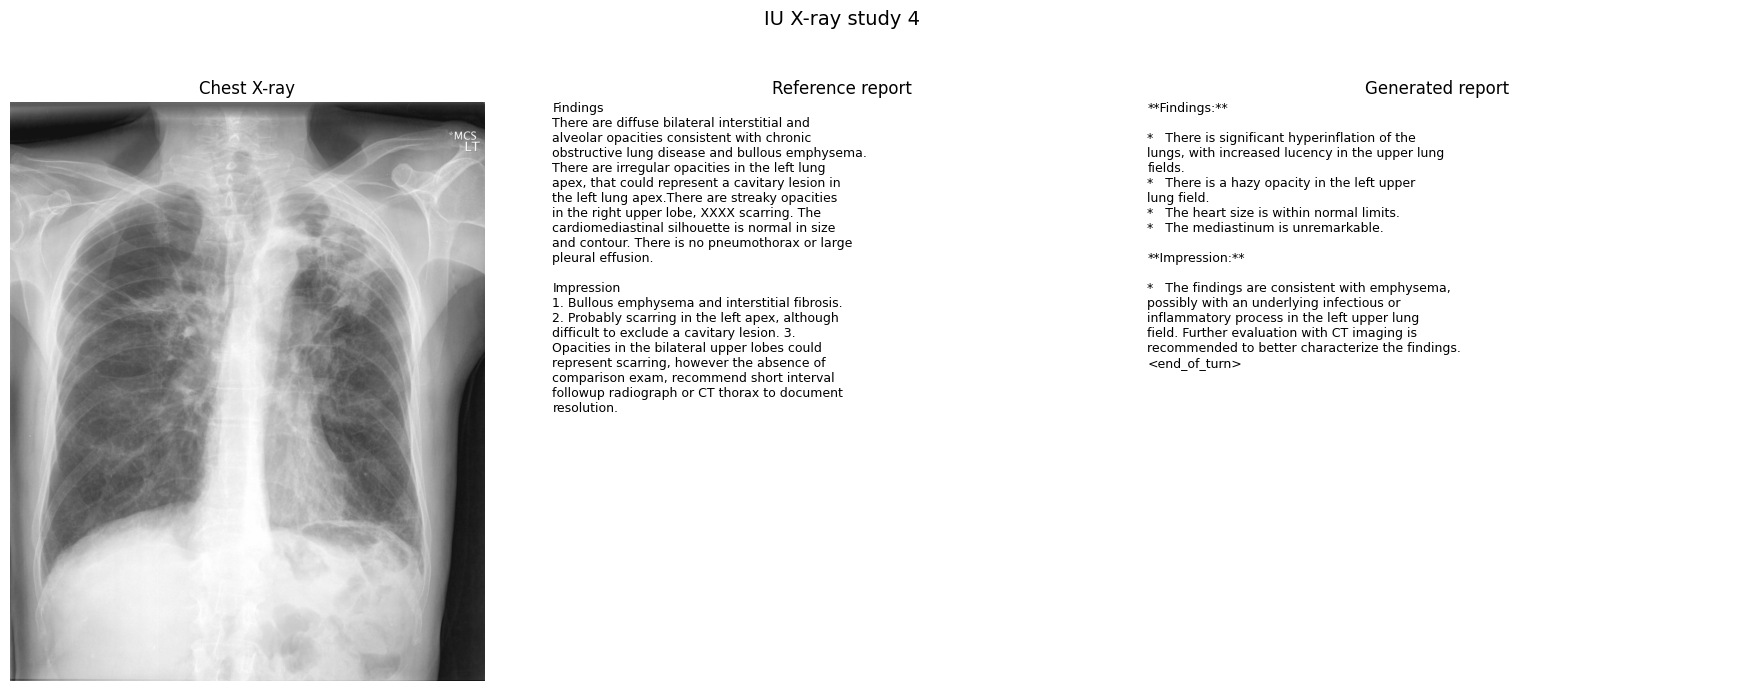

In [25]:
def wrap_report(report, width=48):
    """Wrap report lines without discarding section breaks."""
    return "\n".join(
        textwrap.fill(line, width=width) if line else ""
        for line in report.splitlines()
    )


def add_report_panel(axis, title, report, width=48):
    """Render report text in a Matplotlib axis."""
    axis.text(
        0, 1, wrap_report(report, width),
        va="top", ha="left", fontsize=9, transform=axis.transAxes,
    )
    axis.set_title(title)
    axis.axis("off")


# Place the image, reference, and generated report side by side.
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
axes[0].imshow(image)
axes[0].set_title("Chest X-ray")
axes[0].axis("off")
add_report_panel(axes[1], "Reference report", reference_report)
add_report_panel(axes[2], "Generated report", generated_report)
fig.suptitle(f"IU X-ray study {study['uid']}", fontsize=14)
plt.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

## One-shot visual prompting

One-shot prompting gives MedGemma one labelled training example before a held-out query image. The example contains a frontal chest X-ray and its reference report. The query comes from a separate test split, so its report is not shown to the model.

The experiment records prompt tokens, generated tokens, and runtime so the one-shot result can be compared with the zero-shot baseline.

In [26]:
# Reproducible 80/10/10 study split.
train_studies, validation_studies, test_studies = np.split(
    studies.sample(frac=1, random_state=SEED).reset_index(drop=True),
    [int(.8 * len(studies)), int(.9 * len(studies))],
)
support = train_studies.iloc[0]
query = test_studies.iloc[0]
support_image, query_image = (
    load_xray(support["image_path"]),
    load_xray(query["image_path"]),
)
support_report = format_reference(support)


def make_one_shot_messages(support_image, support_report, query_image):
    return [
        {"role": "system", "content": [{"type": "text", "text": SYSTEM_PROMPT}]},
        {"role": "user", "content": [
            {"type": "text", "text": "Use this labelled example as a guide."},
            {"type": "image", "image": support_image},
        ]},
        {"role": "assistant", "content": [{"type": "text", "text": support_report}]},
        {"role": "user", "content": [
            {"type": "text", "text": PROMPT},
            {"type": "image", "image": query_image},
        ]},
    ]


def generate_with_stats(messages):
    batch = move_batch_to_gpu(
        encode_messages(messages, add_generation_prompt=True), model.device
    )
    prompt_tokens = batch["input_ids"].shape[1]
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    start = __import__("time").perf_counter()
    with torch.inference_mode():
        output = model.generate(
            **batch, do_sample=False, use_cache=True,
            max_new_tokens=MAX_NEW_TOKENS,
        )
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    tokens = output[0, prompt_tokens:]
    return {
        "report": processor.decode(tokens, skip_special_tokens=True).strip(),
        "prompt_tokens": int(prompt_tokens),
        "generated_tokens": int(tokens.numel()),
        "runtime_seconds": __import__("time").perf_counter() - start,
    }


one_shot_result = generate_with_stats(
    make_one_shot_messages(support_image, support_report, query_image)
)
print(one_shot_result["report"])


/usr/local/lib/python3.13/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


Findings:

*   The lungs appear clear without evidence of acute consolidation or significant interstitial edema.
*   The heart size is within normal limits.
*   The mediastinum is unremarkable.
*   The bony structures are intact.

Impression:

No acute cardiopulmonary abnormalities identified on this chest X-ray.
<end_of_turn>


## Quantitative and qualitative evaluation

Zero-shot (`K=0`) and one-shot (`K=1`) prompting are evaluated on held-out studies across multiple seeds. Reports are mapped to a binary normal/abnormal proxy label using explicit normal-report phrases. The results summarize macro-F1, runtime, prompt tokens, and generated tokens as mean ± standard deviation, and show one success and one failure for each setting.

  seed          f1        prompt_tokens         generated_tokens          \
  mean  std   mean    std          mean     std             mean     std   
k                                                                          
0  1.0  1.0  0.398  0.067       309.000   0.000           72.250   4.819   
1  1.0  1.0  0.409  0.078       634.333  18.148           56.567  10.754   

  runtime_seconds         
             mean    std  
k                         
0          12.314  0.485  
1          13.401  1.343  


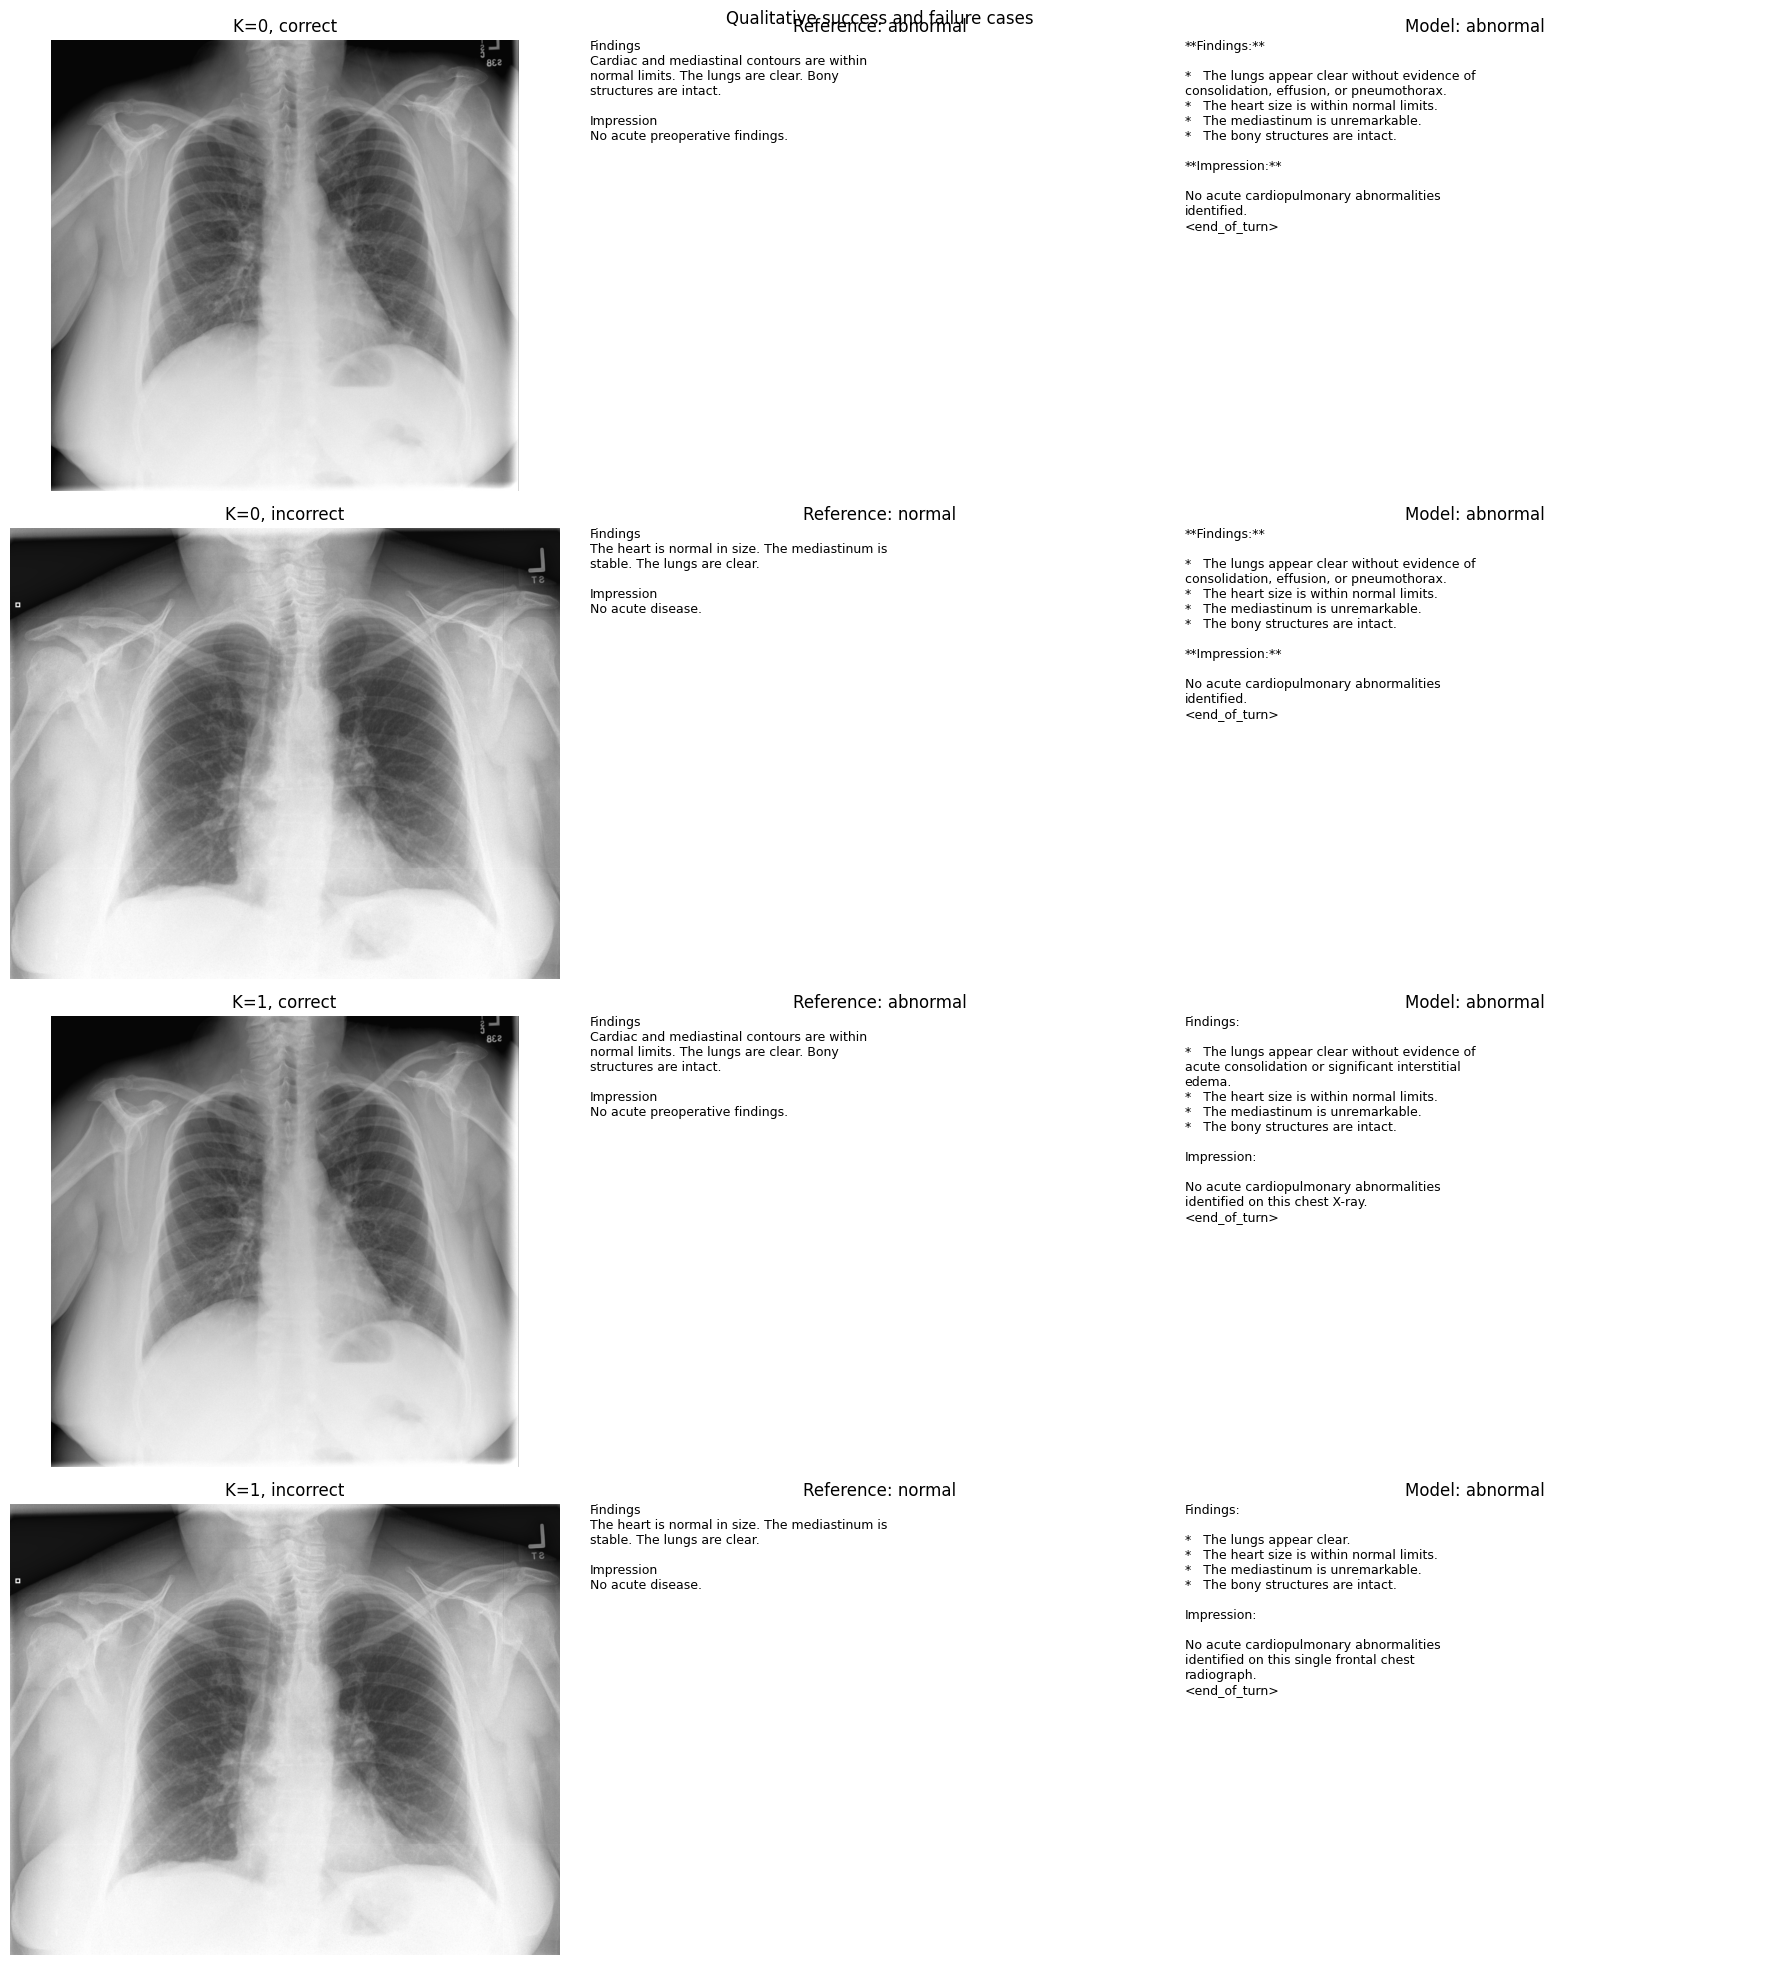

In [27]:
from sklearn.metrics import f1_score

EVALUATION_SEEDS = (0, 1, 2)
EVALUATION_TEST_STUDIES = 20
NORMAL_PHRASES = (
    "no acute cardiopulmonary abnormality",
    "no acute cardiopulmonary disease",
    "no acute cardiopulmonary process",
    "no active cardiopulmonary disease",
    "no acute disease",
    "no acute findings",
    "normal chest",
    "normal exam",
)


def classify_report(report):
    return "normal" if any(p in report.casefold() for p in NORMAL_PHRASES) else "abnormal"


rows = []
for seed in EVALUATION_SEEDS:
    train, _, test = np.split(
        studies.sample(frac=1, random_state=seed).reset_index(drop=True),
        [int(.8 * len(studies)), int(.9 * len(studies))],
    )
    support = train.iloc[0]
    support_image = load_xray(support["image_path"])
    support_report = format_reference(support)
    for _, study in test.head(EVALUATION_TEST_STUDIES).iterrows():
        image = load_xray(study["image_path"])
        reference = format_reference(study)
        label = classify_report(reference)
        for k, messages in (
            (0, make_messages(image, PROMPT)),
            (1, make_one_shot_messages(support_image, support_report, image)),
        ):
            result = generate_with_stats(messages)
            predicted = classify_report(result["report"])
            rows.append({
                "seed": seed, "k": k, "uid": study["uid"],
                "image_path": study["image_path"],
                "reference_report": reference,
                "generated_report": result["report"],
                "reference_label": label, "predicted_label": predicted,
                "correct": label == predicted, **result,
            })

results = pd.DataFrame(rows)
metric_rows = []
for (seed, k), group in results.groupby(["seed", "k"]):
    metric_rows.append({
        "seed": seed, "k": k,
        "f1": f1_score(
            group["reference_label"], group["predicted_label"],
            labels=["normal", "abnormal"], average="macro", zero_division=0,
        ),
        **group[["prompt_tokens", "generated_tokens", "runtime_seconds"]].mean().to_dict(),
    })
metrics = pd.DataFrame(metric_rows)
print(metrics.groupby("k").agg(["mean", "std"]).round(3))

examples = []
for k in sorted(results["k"].unique()):
    group = results[results["k"].eq(k)]
    examples += [
        group[group["correct"].eq(correct)].iloc[0]
        for correct in (True, False)
        if group["correct"].eq(correct).any()
    ]

if examples:
    figure, axes = plt.subplots(
        len(examples), 3, figsize=(18, 5 * len(examples)), squeeze=False
    )
    for row, example in enumerate(examples):
        axes[row, 0].imshow(load_xray(example["image_path"]))
        axes[row, 0].set_title(
            f"K={int(example['k'])}, "
            f"{'correct' if example['correct'] else 'incorrect'}"
        )
        axes[row, 0].axis("off")
        add_report_panel(
            axes[row, 1], f"Reference: {example['reference_label']}",
            example["reference_report"],
        )
        add_report_panel(
            axes[row, 2], f"Model: {example['predicted_label']}",
            example["generated_report"],
        )
    figure.suptitle("Qualitative success and failure cases")
    plt.tight_layout()
    plt.show()


### Questions for the generated report

1. Which statements appear supported by both the image and reference report?
2. Which  findings did the generated report omit?
3. Did the model introduce new/unsupported findings?
4. How does changing the `PROMPT` affect the output?